# Detección de Fraude en Transacciones con Tarjetas de Crédito  
**Isolation Forest – Anomaly Detection**

**Objetivo:**  
Construir un sistema de detección de anomalías capaz de identificar transacciones fraudulentas en un conjunto de datos altamente desbalanceado (~0.17% fraudes).

**Metodología:** CRISP-DM  
**Tecnologías principales:** Python, scikit-learn (Isolation Forest), pandas, matplotlib/seaborn

**Dataset:**  
Credit Card Fraud Detection – Kaggle  
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
(Transacciones de septiembre 2013 – Europa – Variables PCA + Time + Amount)

## 1. Imports y configuración

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, auc

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Lectura y exploración inicial

In [3]:
# Leer el dataset
df = pd.read_csv("../data/creditcard.csv")

print("Dimensiones:", df.shape)
print("\nDistribución de la variable objetivo:")
print(df["Class"].value_counts(normalize=True) * 100)

# Vista rápida
df.head(6)

Dimensiones: (284807, 31)

Distribución de la variable objetivo:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0


In [4]:
# Información básica
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Estadísticos descriptivos (especialmente Amount y Time)
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


c:\Users\prueba\anaconda3\envs\Curso_Machine_Learning\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\prueba\anaconda3\envs\Curso_Machine_Learning\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


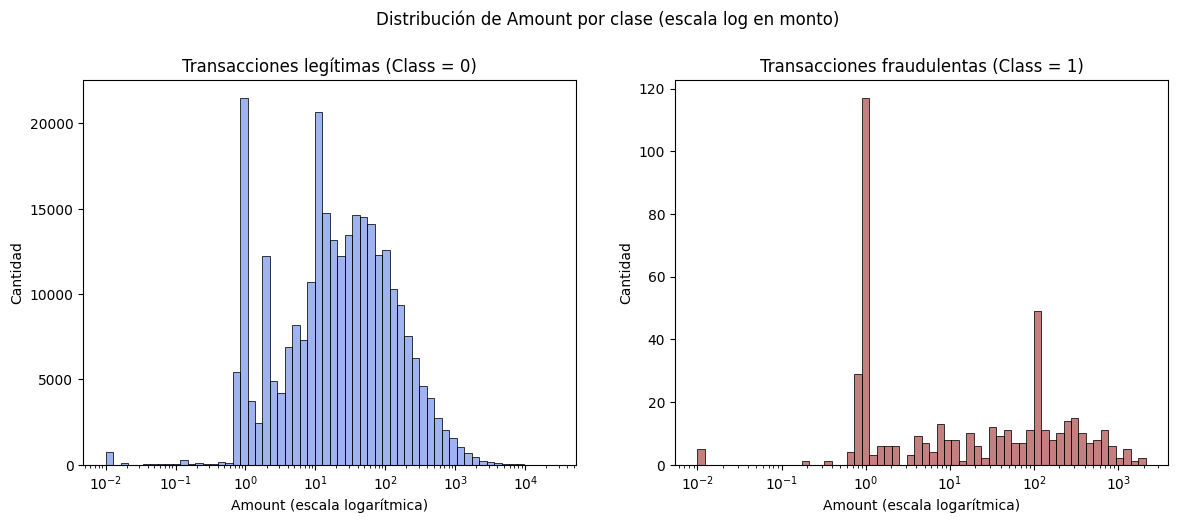

In [ ]:
# Distribución de Amount por clase

# Figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# Izquierda: transacciones normales
sns.histplot(
    data=df[df['Class'] == 0],
    x='Amount',
    bins=60,
    kde=True,
    color='royalblue',
    ax=axes[0],
    log_scale=(True, False)   # log en x (Amount), count normal en y
)
axes[0].set_title('Transacciones legítimas (Class = 0)')
axes[0].set_xlabel('Amount (escala logarítmica)')
axes[0].set_ylabel('Cantidad')

# Derecha: fraudes
sns.histplot(
    data=df[df['Class'] == 1],
    x='Amount',
    bins=60,
    kde=True,
    color='darkred',
    ax=axes[1],
    log_scale=(True, False)
)
axes[1].set_title('Transacciones fraudulentas (Class = 1)')
axes[1].set_xlabel('Amount (escala logarítmica)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.suptitle('Distribución de Amount por clase (escala log en monto)', y=1.02)
plt.show()

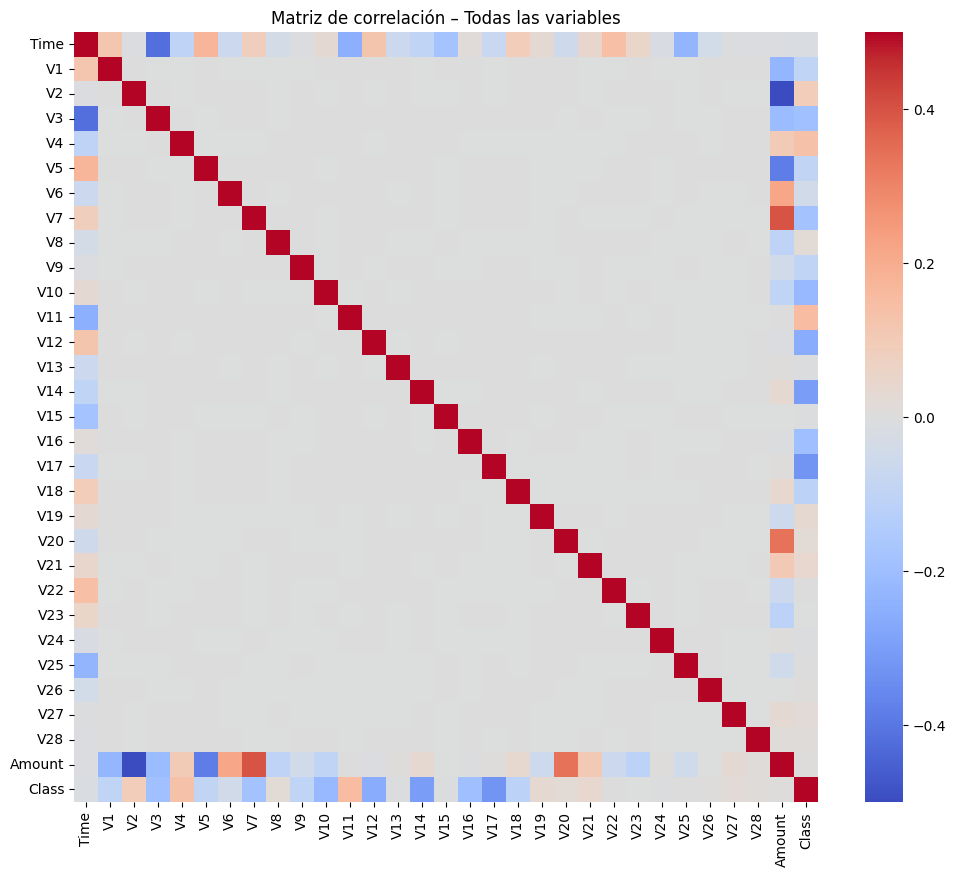

In [9]:
# Matriz de correlación (solo las variables más relevantes visualmente)
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5)
plt.title("Matriz de correlación – Todas las variables")
plt.show()

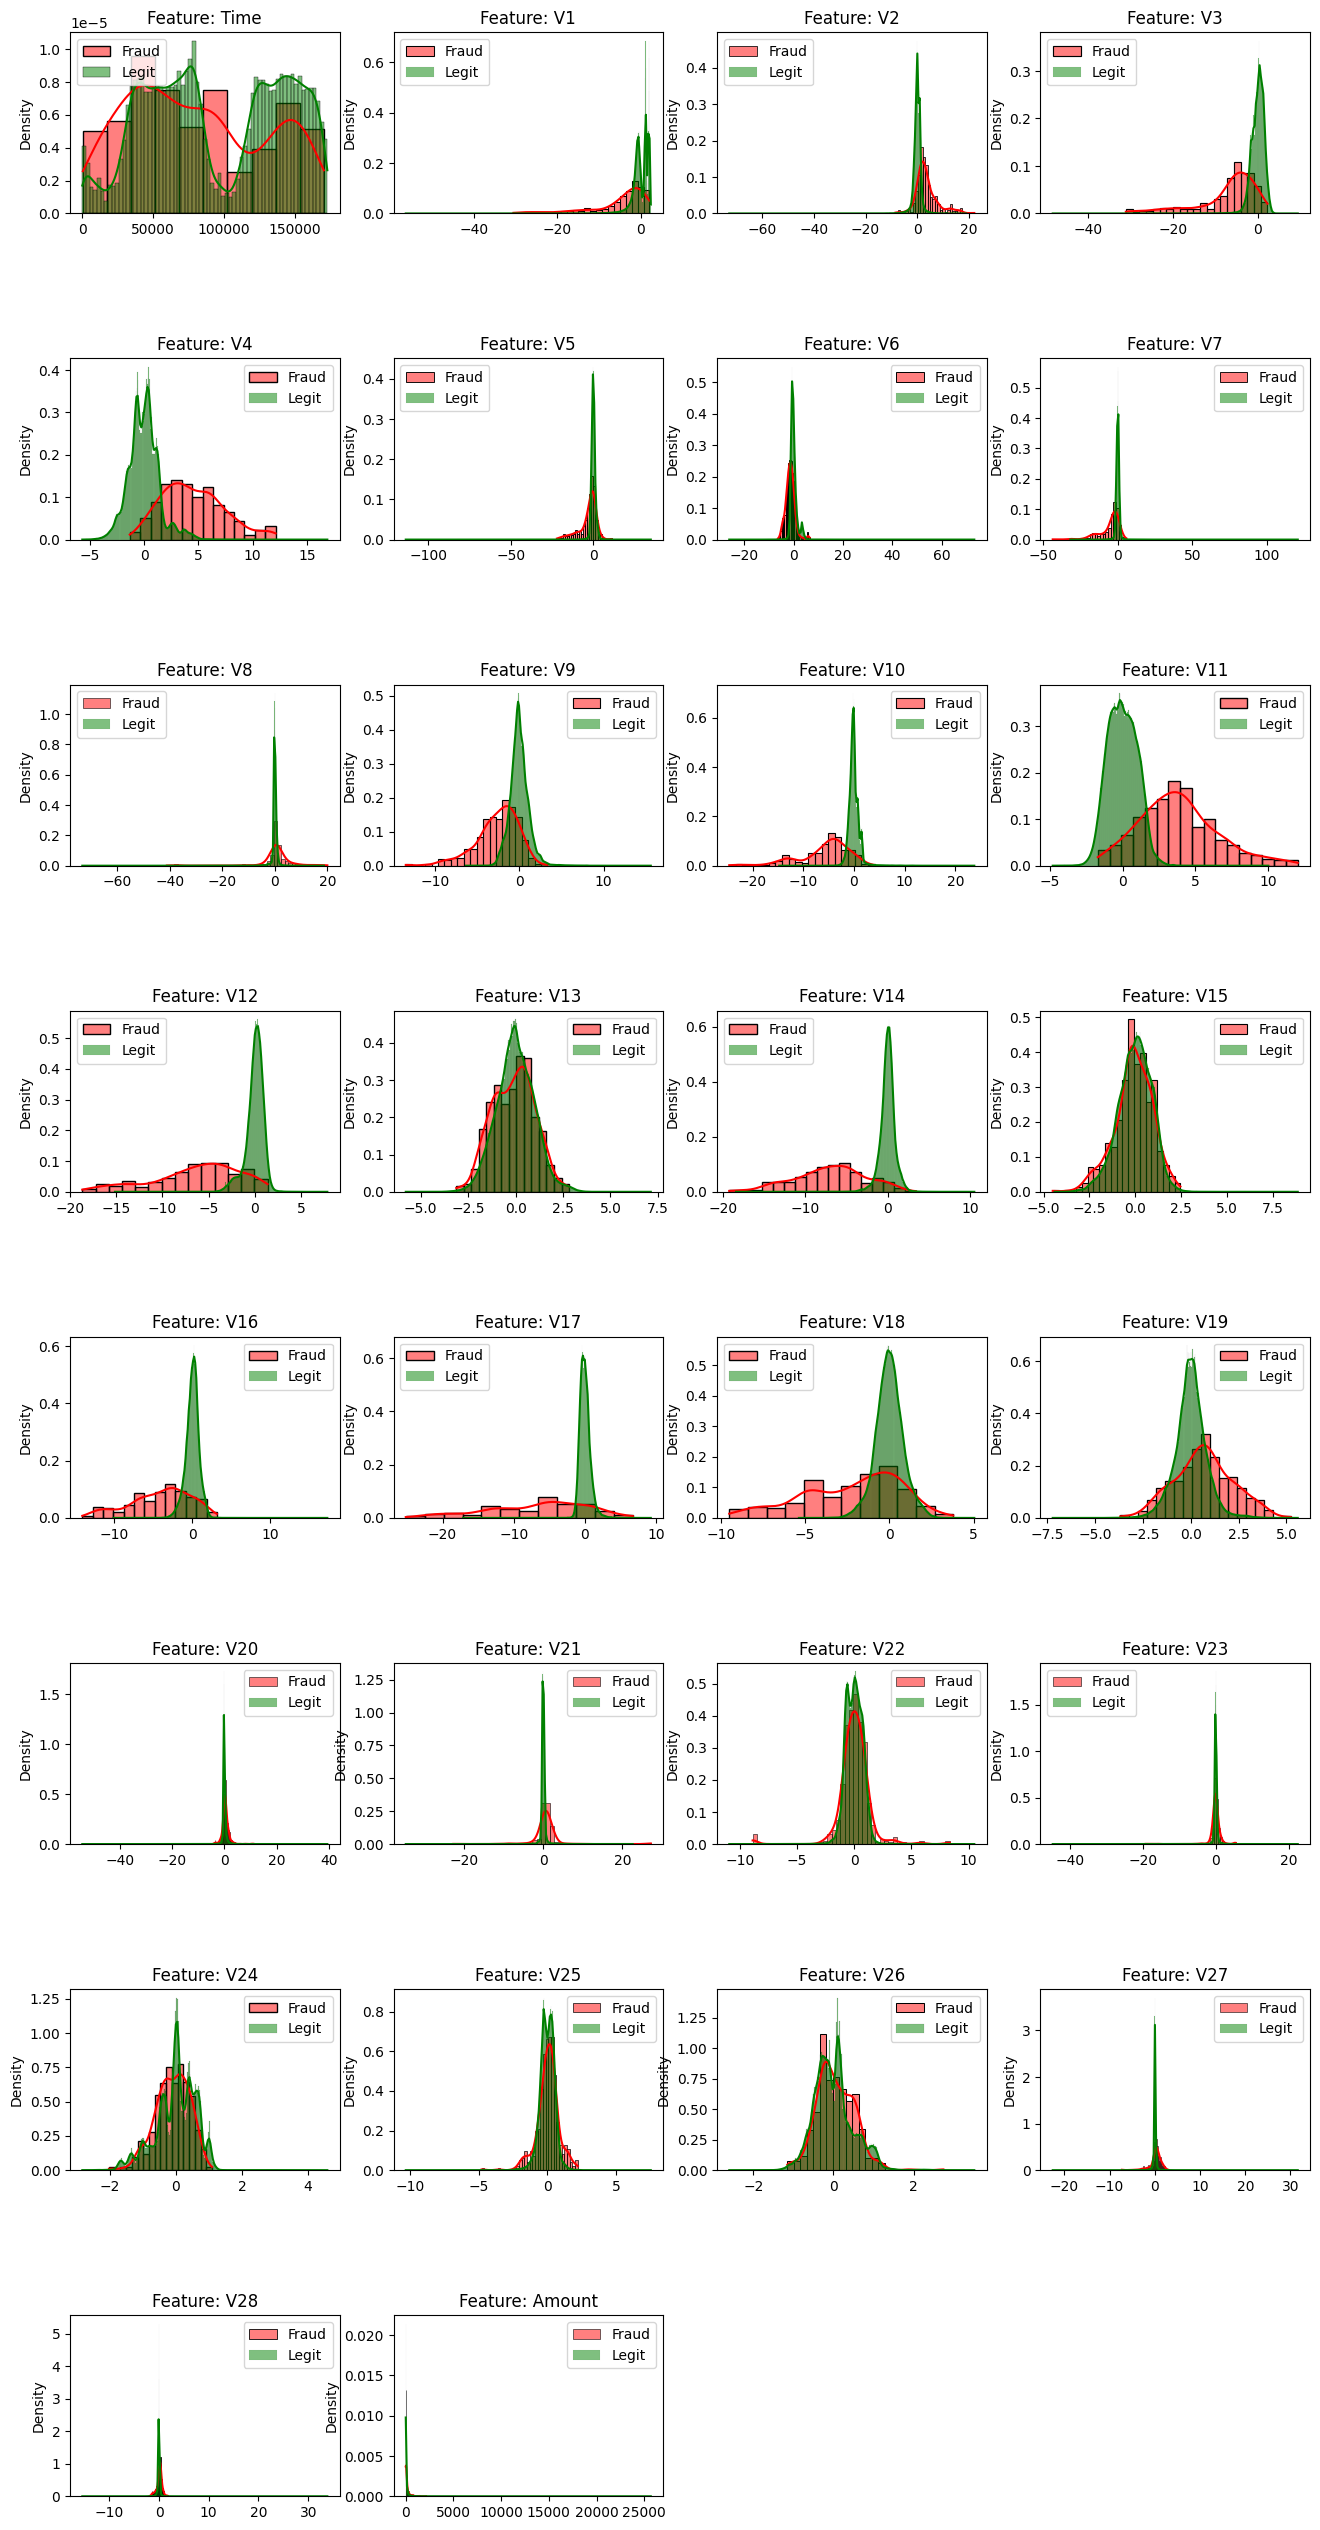

In [12]:
# Representamos gráficamente las características
features = df.drop("Class", axis=1)

plt.figure(figsize=(16, 32))
gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde Class == 1
    sns.histplot(data=df[df["Class"] == 1], x=f, kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
    # Usando histplot para los casos donde Class == 0
    sns.histplot(data=df[df["Class"] == 0], x=f, kde=True, color="green", stat="density", label="Legit", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

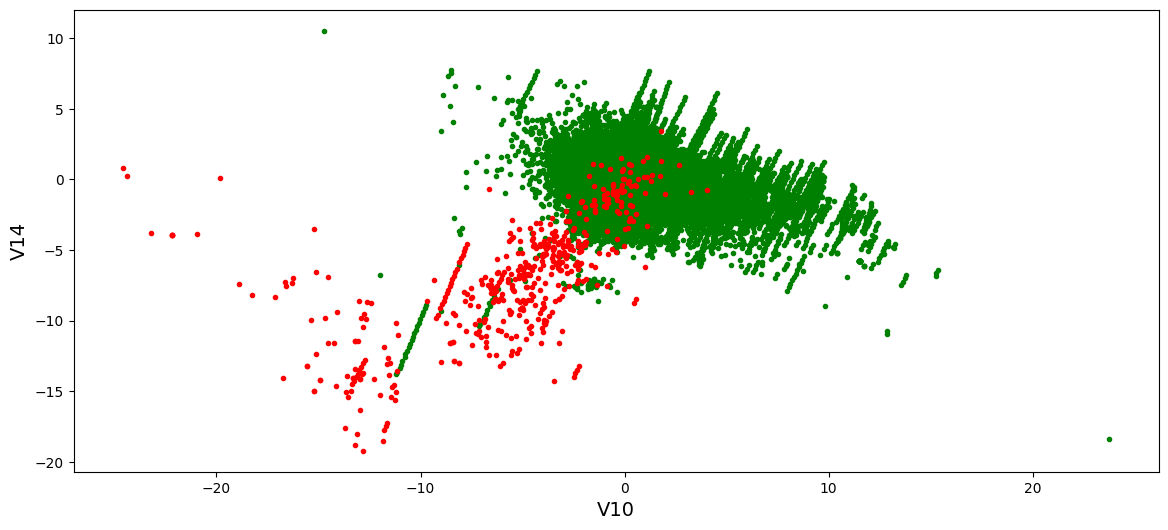

In [13]:
# Representación gráfica de dos características
plt.figure(figsize=(14, 6))
plt.scatter(df["V10"][df['Class'] == 0], df["V14"][df['Class'] == 0], c="g", marker=".")
plt.scatter(df["V10"][df['Class'] == 1], df["V14"][df['Class'] == 1], c="r", marker=".")
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

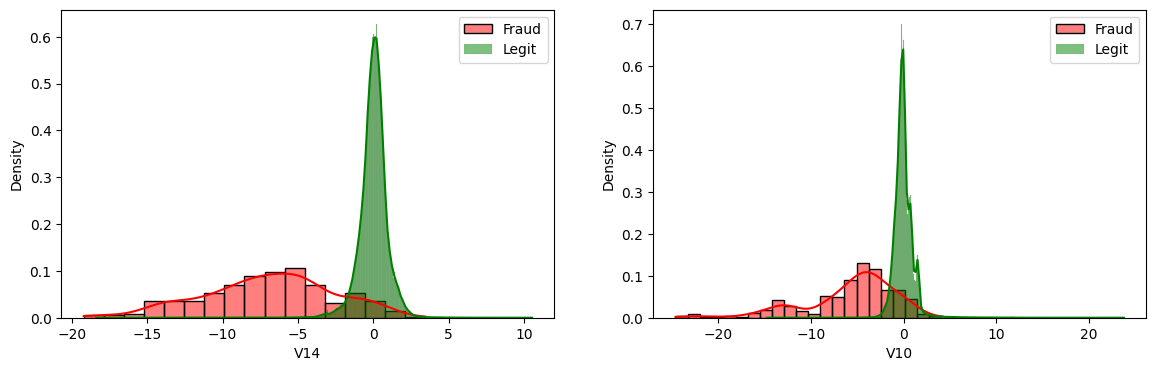

In [14]:
plt.figure(figsize=(14,4))
gs = gridspec.GridSpec(1, 2)

# Representación de la característica 1
ax = plt.subplot(gs[0])
sns.histplot(data=df[df['Class'] == 1], x="V14", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V14", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

# Representación de la característica 2
ax = plt.subplot(gs[1])
sns.histplot(data=df[df['Class'] == 1], x="V10", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V10", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

plt.show()

## 3. Preprocesamiento

In [15]:
# Escalado robusto (mejor para datos con outliers como Amount)
robust = RobustScaler()

df["Amount_scaled"] = robust.fit_transform(df[["Amount"]])
df["Time_scaled"]   = robust.fit_transform(df[["Time"]])

# Eliminamos las columnas originales
df = df.drop(columns=["Amount", "Time"])

# Features y target
X = df.drop(columns=["Class"])
y = df["Class"]

print("Preprocesamiento terminado")
print("X shape:", X.shape)

Preprocesamiento terminado
X shape: (284807, 30)


## 4. Separación train/test (estratificada)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

# Muy importante: Isolation Forest se entrena SOLO con datos normales
X_train_normal = X_train[y_train == 0]

print(f"Entrenamiento – solo normales: {X_train_normal.shape[0]:,} registros")
print(f"Test total: {X_test.shape[0]:,} registros (fraudes reales: {y_test.sum():,})")

Entrenamiento – solo normales: 213,236 registros
Test total: 71,202 registros (fraudes reales: 123)


## 5. Modelo base: Insolation Forest

Reporte de clasificación – Modelo base
              precision    recall  f1-score   support

           0     0.9987    0.9983    0.9985     71079
           1     0.2000    0.2439    0.2198       123

    accuracy                         0.9970     71202
   macro avg     0.5993    0.6211    0.6091     71202
weighted avg     0.9973    0.9970    0.9972     71202



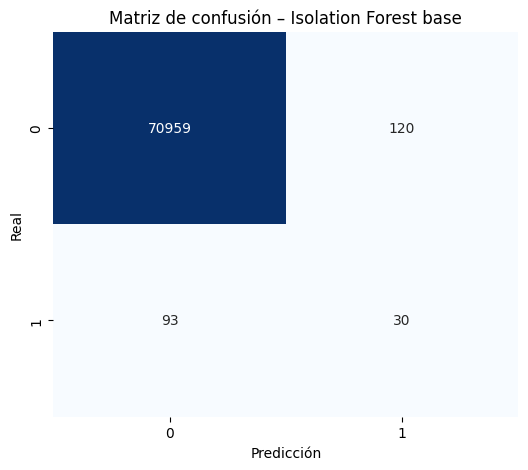

In [17]:
iso_forest = IsolationForest(
    n_estimators=250,
    contamination=0.0017,          # ≈ tasa real de fraude
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Entrenamos SOLO con transacciones normales
iso_forest.fit(X_train_normal)

# Predicción en test
y_pred = iso_forest.predict(X_test)

# -1 → anomalía (fraude) → 1
#  1 → normal               → 0
y_pred = np.where(y_pred == -1, 1, 0)

print("Reporte de clasificación – Modelo base")
print(classification_report(y_test, y_pred, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión – Isolation Forest base")
plt.show()

## 6. Curva Precision-Recall

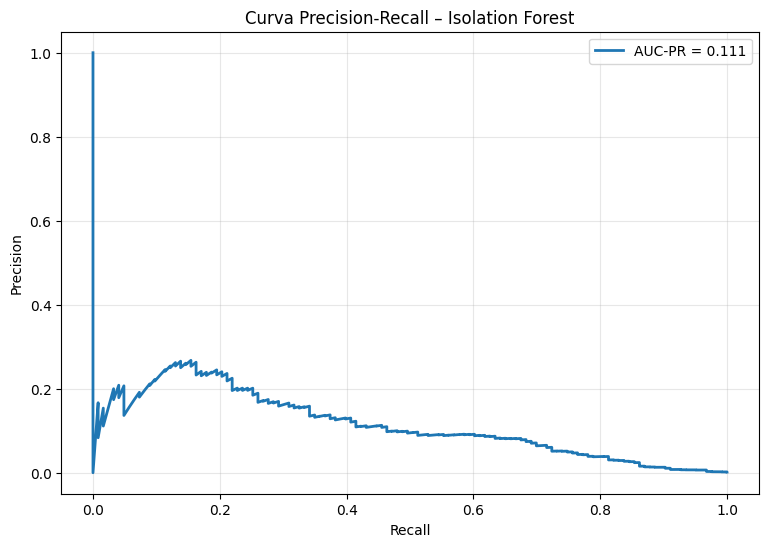

In [18]:
# Obtenemos el score de anomalía (cuanto más negativo → más anómalo)
scores = iso_forest.decision_function(X_test)
# Convertimos a probabilidad aproximada de fraude (heuristic)
proba_fraude = -scores  # valores más altos = más probable fraude

precision, recall, thresholds = precision_recall_curve(y_test, proba_fraude)

plt.figure(figsize=(9,6))
plt.plot(recall, precision, linewidth=2, label=f"AUC-PR = {auc(recall, precision):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall – Isolation Forest")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Búsqueda simple de hiperparámetros (contamination + n_estimators)

In [ ]:
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# 1. Definir la función de scoring personalizada
def custom_f1_anomaly(y_true, y_pred_raw):
    """
    Mapea las salidas del IsolationForest (-1 anomalía, 1 normal)
    a las etiquetas del dataset (1 fraude, 0 normal) antes de calcular el F1.
    """
    y_pred_mapped = np.where(y_pred_raw == -1, 1, 0)
    return f1_score(y_true, y_pred_mapped)

# Crear el scorer para que GridSearchCV lo entienda
f1_anomaly_scorer = make_scorer(custom_f1_anomaly)

# 2. Definir el espacio de búsqueda
param_grid = {
    'n_estimators': [50, 100, 150],
    'contamination': [0.001, 0.002, 0.01, 'auto']
}

# 3. Configurar GridSearchCV
grid = GridSearchCV(
    IsolationForest(random_state=RANDOM_STATE, max_samples="auto", n_jobs=-1),
    param_grid,
    cv=3,
    scoring=f1_anomaly_scorer, # <-- Implementación del scorer personalizado
    n_jobs=-1,
    verbose=1
)

# Nota: Pasamos (X_train, y_train) a GridSearchCV.
# El IsolationForest internamente ignora y_train durante el entrenamiento de cada pliegue,
# pero GridSearchCV utiliza las etiquetas reales del conjunto de validación de cada pliegue 
# para calcular el score F1 (usando nuestra función) y elegir los mejores hiperparámetros.
grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid.best_params_)
print("Mejor score F1 en Validación Cruzada:", grid.best_score_.round(4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados: {'contamination': 0.001, 'n_estimators': 50}
Mejor score F1 en Validación Cruzada: 0.2912


Reporte – Mejor modelo de GridSearch
              precision    recall  f1-score   support

           0     0.9986    0.9992    0.9989     71079
           1     0.3077    0.1951    0.2388       123

    accuracy                         0.9979     71202
   macro avg     0.6532    0.5972    0.6189     71202
weighted avg     0.9974    0.9979    0.9976     71202



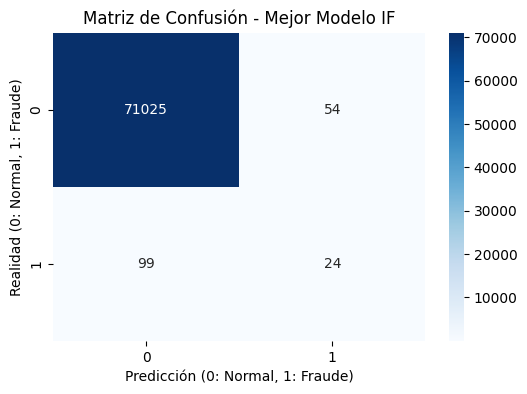

In [22]:
# Evaluación del mejor modelo en test
best_model = grid.best_estimator_

# Generar predicciones con el mejor modelo
y_pred_best = best_model.predict(X_test)

# Ajustar las etiquetas (-1, 1) a las del dataset (1, 0)
y_pred_best = np.where(y_pred_best == -1, 1, 0)

print("Reporte – Mejor modelo de GridSearch")
print(classification_report(y_test, y_pred_best, digits=4))

# Matriz de confusión
plt.figure(figsize=(6, 4))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Mejor Modelo IF")
plt.xlabel("Predicción (0: Normal, 1: Fraude)")
plt.ylabel("Realidad (0: Normal, 1: Fraude)")
plt.show()

### Análisis del mejor modelo (GridSearchCV)
- **F1-score clase fraude = 0.239** → razonable para un detector no supervisado en dataset altamente desbalanceado.
- Precision mejorada vs baseline (30.8% vs ~20%), pero recall más bajo (19.5%).
- Muy pocos falsos positivos (solo 54 en 71k transacciones legítimas) → útil para no molestar usuarios reales.
- Limitación típica de Isolation Forest: prioriza anomalías muy claras → deja pasar fraudes "sutiles".
- En producción: combinar con reglas de negocio (e.g., monto > $200 + hora nocturna) o usar como filtro inicial antes de un modelo supervisado.

## Conclusiones y Resumen de Impacto

En este proyecto se implementó **Isolation Forest** como método no supervisado para detectar transacciones fraudulentas en el dataset *Credit Card Fraud Detection* (Kaggle), caracterizado por un desbalance extremo (~0.172% de fraudes, solo ~492 casos positivos en ~284.807 transacciones).

### Resultados principales en el conjunto de test (~71.202 transacciones, 123 fraudes reales)

**Modelo base** (contamination ≈ 0.0017, n_estimators=250)  
- Recall (sensibilidad): **~24.4%** → detectó 30 de 123 fraudes  
- Precision: **~20.0%** → de cada 5 alertas generadas, solo 1 era fraude real  
- F1-score (clase fraude): **~22%**  
- Falsos positivos: 120 → FPR ≈ 0.17%

**Mejor modelo optimizado** (GridSearchCV: contamination=0.001, n_estimators=50)  
- Recall: **19.5%** → detectó 24 de 123 fraudes  
- Precision: **30.8%** → mejora notable en la calidad de las alertas  
- F1-score (clase fraude): **23.9%**  
- Falsos positivos: **solo 54** → FPR ≈ 0.076% (excelente control)

### Impacto y calidad de detección lograda

- El modelo destaca por su **control excepcional de falsos positivos** (FPR < 0.1% en el mejor caso), lo cual es **crítico en entornos reales** ya que evita generar miles de verificaciones innecesarias a clientes legítimos y reduce costos operativos asociados a revisiones manuales.
- Aunque el recall es moderado-bajo (~19–24%), este comportamiento es **consistente y esperado** en enfoques puramente no supervisados aplicados a datos transformados con PCA, sin acceso a etiquetas durante el entrenamiento.
- La optimización de hiperparámetros permitió **mejorar la precisión** (de ~20% a ~31%), generando alertas **más confiables** y reduciendo significativamente el volumen de falsos positivos.
- AUC-PR ≈ 0.111 (baseline) → alineado con resultados típicos reportados en literatura y experimentos no supervisados sobre este dataset.

### Valor en contexto de negocio

Isolation Forest se posiciona como un **detector inicial robusto, de bajo costo y sin necesidad de grandes volúmenes de datos etiquetados**.  
Su principal fortaleza radica en:

- Minimizar el impacto negativo en la experiencia del usuario legítimo  
- Servir como filtro de primer nivel en sistemas de detección de fraude en tiempo real  
- Complementar reglas de negocio y modelos supervisados más complejos en etapas posteriores

En un escenario productivo, capturar ~20–25% de los fraudes con muy pocas alarmas falsas representa un **valor significativo** para reducir pérdidas económicas sin deteriorar la satisfacción del cliente.

Este proyecto demuestra capacidad para:
- Manejar datasets altamente desbalanceados de forma efectiva  
- Aplicar y evaluar métodos de detección de anomalías no supervisados  
- Interpretar trade-offs clave (precision vs recall vs costo operativo)  
- Comunicar resultados técnicos con orientación a impacto de negocio

**Próximos pasos sugeridos:**  
- Explorar contamination más altos (0.005–0.02) para mejorar recall  
- Calibrar umbral dinámico con curva Precision-Recall  
- Comparar con otros métodos no supervisados (LOF, Autoencoder) y enfoques semi-supervisados 
- Un enfoque supervisado puede lograr recall >80% con F1 ~0.75–0.85 (según notebooks de la comunidad en Kaggle)
- Integrar reglas de negocio simples para potenciar la detección